# 통합 보행 보조 파이프라인 v4

**v3 문제점 분석**

| 케이스 | v3 결과 | 실제 상황 | 원인 |
|--------|--------|----------|------|
| `frame_70` | "정지! 2시 차량 빠르게 접근" | 차는 멀리 있음 (작은 detection, conf=0.335, motion=static) | **depth 노이즈로 `_approach_mps`가 양수**, 낮은 confidence 객체에도 안내 |
| `frame_644` | "1시 버스 우회" | 버스는 화면 윗부분 작은 영역 (멀리) | **depth 추정이 작은/먼 객체에 부정확** — 18,000px짜리 버스에 3.77m 산출 |
| `frame_560` | car/person 4개만 | YOLO 단독은 13개 객체 잡음 | `det_model.track()`이 ByteTrack 매칭에서 일부 detection을 떨어뜨림 |

**핵심 진단** — depth 추정값이 작거나 먼 객체에 대해 신뢰할 수 없음. bbox 크기/위치로 sanity check 필요.

**v4 변경점**
1. **거리 임계 강화**: `URGENT=2.5 / ALERT=3.0 / MAX_GUIDE=3.5` (요청 반영)
2. **Depth + bbox 크기 일관성 검증**: bbox 높이/면적으로 거리 sanity check. 작은 bbox(멀리 있는 거)인데 depth가 가깝게 나오면 bbox 기반 추정으로 보정.
3. **Confidence 임계**: `MIN_GUIDE_CONF = 0.45`. 이하 객체는 안내 후보 X.
4. **`approach_mps`는 `motion=moved`일 때만 신뢰**. static 객체에 "다가옴" 판단 X.
5. **urgent (정지)는 cooldown 무시** — 위험은 계속 알림.
6. **단계별 처리시간 분리**: detection/tracking/segmentation/depth 각각 측정.
7. **Detection 누락 분석 셀 추가**: `predict` vs `track` 비교.

**최종 출력**
- 프레임별 JSON (`json/<frame>.json`) + 전체 (`all_results.jsonl`)
- gt만 모은 JSON (`gt_only.json`)
- 시각화 (`viz/<frame>_viz.png`)
- 단계별 처리시간 통계


## 1. 환경 + 의존성

In [30]:
!nvidia-smi -L
import torch
print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")


GPU 0: NVIDIA RTX PRO 6000 Blackwell Server Edition (UUID: GPU-264650a9-7b7f-94f3-8ef3-1705edfc844c)
PyTorch: 2.10.0+cu128, CUDA: True


In [31]:
!pip install -q -U transformers
!pip install -q -U ultralytics
!pip install -q scipy lap


In [32]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. 경로 / 하이퍼파라미터 설정

In [33]:
import os
from pathlib import Path

# ===== 입력 =====
TEST_IMAGE_DIR = "/content/drive/MyDrive/capstone/test1_school_frames_2fps"

# ===== 모델 가중치 =====
YOLO_DET_WEIGHTS = "/content/drive/MyDrive/capstone/models/detection/yolo11s/weights/bestv3.pt"
YOLO_SEG_WEIGHTS = "/content/drive/MyDrive/capstone/models/segmentation/best_yoloseg.pt"

# ===== 출력 =====
OUTPUT_DIR = "/content/drive/MyDrive/capstone/results/integrated_pipeline_v4"
os.makedirs(OUTPUT_DIR, exist_ok=True)
JSON_DIR = os.path.join(OUTPUT_DIR, "json")
VIZ_DIR  = os.path.join(OUTPUT_DIR, "viz")
os.makedirs(JSON_DIR, exist_ok=True)
os.makedirs(VIZ_DIR, exist_ok=True)

# ===== 하이퍼파라미터 =====
IMG_SIZE = 480
CONF_DET = 0.25      # detection threshold (트래커가 살릴지 결정)
CONF_SEG = 0.25
MIN_GUIDE_CONF = 0.45   # 안내 후보가 되려면 이 이상 confidence (낮은 conf로 인한 false alarm 방지)

# ----- 거리 임계값 (미터) -----  ← 사용자 요청대로
URGENT_DISTANCE_M = 3.0
ALERT_DISTANCE_M  = 3.5
MAX_GUIDE_DISTANCE_M = 4.0

NEAR_M = 3.0
MID_M  = 4.0

# ----- 거대 bbox(코앞 객체) 임계 -----
HUGE_BBOX_AREA_RATIO = 0.20   # bbox가 화면의 20%↑이면 거대
HUGE_BBOX_MAX_DIST   = 5.0    # 거대 bbox이면서 5m 이내면 위험

# ----- 빠른 차량 접근 정지 -----
VEHICLE_APPROACH_THRESH = 0.4   # m/frame
VEHICLE_STOP_DISTANCE   = 4.0
VEHICLE_MIN_TRACK_AGE   = 5     # 트랙이 안정될 때까지 더 대기

# ----- motion 판단 -----
MOTION_PIXEL_THRESHOLD = 8.0
TRACK_HISTORY_LEN = 8

# ----- 시계방향 보행 시야 -----
WALKING_VIEW_HOURS = {9, 10, 11, 12, 1, 2, 3}

# ----- Cooldown -----
ANNOUNCEMENT_COOLDOWN_FRAMES = 6   # 같은 track으로 최근 안내했으면 스킵 (단, urgent stop은 예외)

# ----- Depth + bbox sanity check -----
# bbox 높이가 IMG_HEIGHT의 이 비율보다 작으면 "멀리 있는 객체"로 간주
SMALL_BBOX_HEIGHT_RATIO = 0.20      # bbox 높이가 화면 높이의 20% 미만 = 작은 객체
# 작은 객체에 대해 depth가 이 미만으로 나오면 신뢰 X (실제로는 더 멀 것)
SMALL_BBOX_MIN_TRUST_DIST = 5.0

# ----- 입력 이미지 목록 -----
img_files = sorted([p for p in Path(TEST_IMAGE_DIR).iterdir()
                    if p.suffix.lower() in ['.jpg', '.jpeg', '.png']])
print(f"테스트 이미지: {len(img_files)}장")
print(f"결과 경로: {OUTPUT_DIR}")


테스트 이미지: 93장
결과 경로: /content/drive/MyDrive/capstone/results/integrated_pipeline_v4


## 3. 모델 로드

In [34]:
from ultralytics import YOLO

print("YOLO detection 모델 로드 중...")
det_model = YOLO(YOLO_DET_WEIGHTS)
print(f"  classes: {det_model.names}")

print("\nYOLO segmentation 모델 로드 중...")
seg_model = YOLO(YOLO_SEG_WEIGHTS)
print(f"  classes: {seg_model.names}")


YOLO detection 모델 로드 중...
  classes: {0: 'wheelchair', 1: 'truck', 2: 'tree_trunk', 3: 'traffic_sign', 4: 'traffic_light', 5: 'traffic_light_controller', 6: 'table', 7: 'stroller', 8: 'stop', 9: 'scooter', 10: 'potted_plant', 11: 'power_controller', 12: 'pole', 13: 'person', 14: 'parking_meter', 15: 'movable_signage', 16: 'motorcycle', 17: 'kiosk', 18: 'fire_hydrant', 19: 'dog', 20: 'chair', 21: 'cat', 22: 'carrier', 23: 'car', 24: 'bus', 25: 'bollard', 26: 'bicycle', 27: 'bench', 28: 'barricade'}

YOLO segmentation 모델 로드 중...
  classes: {0: 'walkable_surface', 1: 'braille_guide_blocks', 2: 'caution_surface', 3: 'roadway', 4: 'crosswalk'}


In [35]:
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1
print(f"Device: {'cuda' if device == 0 else 'cpu'}")

DEPTH_MODEL_NAME = "depth-anything/Depth-Anything-V2-Metric-Outdoor-Base-hf"
print(f"\n{DEPTH_MODEL_NAME} 로드 중...")
depth_pipe = pipeline(task="depth-estimation", model=DEPTH_MODEL_NAME, device=device)
print("Depth 모델 로드 완료")


Device: cuda

depth-anything/Depth-Anything-V2-Metric-Outdoor-Base-hf 로드 중...


Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

Depth 모델 로드 완료


## 4. 클래스 매핑 / 한국어 라벨

In [36]:
KO_LABEL = {
    'car': '차량', 'truck': '트럭', 'bus': '버스', 'van': '승합차',
    'motorcycle': '오토바이', 'motorbike': '오토바이', 'scooter': '스쿠터',
    'bike': '자전거', 'bicycle': '자전거', 'vehicle': '차량',
    'person': '사람', 'pedestrian': '보행자', 'people': '사람',
    'pole': '기둥', 'tree_trunk': '나무', 'tree': '나무',
    'bollard': '볼라드', 'barrier': '바리케이드', 'cone': '라바콘',
    'fence': '울타리', 'bench': '벤치', 'bin': '쓰레기통',
    'hydrant': '소화전', 'sign': '표지판', 'post': '기둥',
    'traffic_light': '신호등', 'traffic_light_red': '빨간 신호등',
    'traffic_light_green': '파란 신호등',
    'crosswalk': '횡단보도', 'zebra': '횡단보도',
}


def to_ko(name: str) -> str:
    n = name.lower().strip()
    if n in KO_LABEL:
        return KO_LABEL[n]
    for k, v in KO_LABEL.items():
        if k in n:
            return v
    return name


DET_CLASS_NAMES = det_model.names

def categorize_det_class(name: str) -> dict:
    n = name.lower()
    is_tl = ('traffic' in n and 'light' in n) or n.startswith('tl_') or 'signal' in n
    return {
        'is_person':        any(k in n for k in ['person', 'pedestrian', 'people']),
        'is_vehicle':       any(k in n for k in ['car', 'truck', 'bus', 'van', 'vehicle',
                                                  'motorcycle', 'motorbike', 'scooter',
                                                  'bike', 'bicycle']),
        'is_traffic_light': is_tl,
        'is_tl_red':        is_tl and 'red' in n,
        'is_tl_green':      is_tl and (('green' in n) or ('blue' in n)),
        'is_crosswalk':     'crosswalk' in n or 'cross_walk' in n or 'zebra' in n,
        'is_obstacle':      any(k in n for k in ['pole', 'barrier', 'bollard', 'cone',
                                                  'fence', 'tree', 'bench', 'bin',
                                                  'hydrant', 'sign', 'post']),
    }

DET_CAT = {cid: categorize_det_class(nm) for cid, nm in DET_CLASS_NAMES.items()}

print("Detection 클래스 카테고리화:")
for cid, nm in DET_CLASS_NAMES.items():
    cat = DET_CAT[cid]
    flags = [k.replace('is_', '') for k, v in cat.items() if v]
    print(f"  [{cid:2d}] {nm:25s} ({to_ko(nm):8s}) -> {flags}")


Detection 클래스 카테고리화:
  [ 0] wheelchair                (wheelchair) -> []
  [ 1] truck                     (트럭      ) -> ['vehicle']
  [ 2] tree_trunk                (나무      ) -> ['obstacle']
  [ 3] traffic_sign              (표지판     ) -> ['obstacle']
  [ 4] traffic_light             (신호등     ) -> ['traffic_light']
  [ 5] traffic_light_controller  (신호등     ) -> ['traffic_light']
  [ 6] table                     (table   ) -> []
  [ 7] stroller                  (stroller) -> []
  [ 8] stop                      (stop    ) -> []
  [ 9] scooter                   (스쿠터     ) -> ['vehicle']
  [10] potted_plant              (potted_plant) -> []
  [11] power_controller          (power_controller) -> []
  [12] pole                      (기둥      ) -> ['obstacle']
  [13] person                    (사람      ) -> ['person']
  [14] parking_meter             (parking_meter) -> []
  [15] movable_signage           (표지판     ) -> ['obstacle']
  [16] motorcycle                (오토바이    ) -> ['vehicle']
  [17

In [37]:
SEG_CLASS_MAP = {
    0: 'walkable_surface',
    1: 'braille_guide_blocks',
    2: 'caution_surface',
    3: 'roadway',
    4: 'crosswalk',
}

def classify_object(det_name: str) -> dict:
    cat = categorize_det_class(det_name)
    if cat['is_vehicle']:
        return {'risk_type': 'dynamic_watch', 'severity': 3, 'is_dynamic': True}
    if cat['is_person']:
        return {'risk_type': 'informational', 'severity': 1, 'is_dynamic': True}
    if cat['is_obstacle']:
        return {'risk_type': 'path_blocking', 'severity': 2, 'is_dynamic': False}
    if cat['is_traffic_light']:
        return {'risk_type': 'signal',        'severity': 1, 'is_dynamic': False}
    return {'risk_type': 'informational',     'severity': 1, 'is_dynamic': False}

print("classify_object 정의 완료")


classify_object 정의 완료


## 5. 시계방향 / 거리 분류 / 우회 로직

In [38]:
import numpy as np

def x_ratio_to_clock(x_ratio: float) -> str:
    val = (x_ratio - 0.5) * 6.0
    idx = int(round(val))
    idx = max(-3, min(3, idx))
    if idx == 0:
        return "12시"
    elif idx > 0:
        return f"{idx}시"
    else:
        return f"{12 + idx}시"


def clock_to_int(s: str) -> int:
    return int(s.replace('시', ''))


def int_to_clock(h: int) -> str:
    h = ((h - 1) % 12) + 1
    return f"{h}시"


def detour_direction(danger_clock: str, safe_clocks: set):
    h = clock_to_int(danger_clock)
    if 9 <= h <= 12:
        candidates = [int_to_clock(h + 2), int_to_clock(h - 2)]
    elif 1 <= h <= 3:
        candidates = [int_to_clock(h - 2), int_to_clock(h + 2)]
    else:
        candidates = [int_to_clock(h + 2), int_to_clock(h - 2)]
    for c in candidates:
        if c in safe_clocks:
            return c
    fallback = candidates[0] if candidates else None
    if fallback and clock_to_int(fallback) in WALKING_VIEW_HOURS:
        return fallback
    return None


def distance_bin(d_m: float) -> str:
    if d_m < NEAR_M:
        return 'near'
    if d_m < MID_M:
        return 'mid'
    return 'far'


def horiz_region(x_ratio: float) -> str:
    if x_ratio < 1/3:
        return 'left'
    if x_ratio < 2/3:
        return 'center'
    return 'right'


def in_walking_view(clock_str: str) -> bool:
    return clock_to_int(clock_str) in WALKING_VIEW_HOURS


for x in [0.0, 0.16, 0.33, 0.5, 0.66, 0.83, 1.0]:
    print(f"x={x:.2f} -> {x_ratio_to_clock(x)}, region={horiz_region(x)}")


x=0.00 -> 9시, region=left
x=0.16 -> 10시, region=left
x=0.33 -> 11시, region=left
x=0.50 -> 12시, region=center
x=0.66 -> 1시, region=center
x=0.83 -> 2시, region=right
x=1.00 -> 3시, region=right


## 6. Depth & Segmentation 헬퍼

**v4 핵심**: bbox 크기로 거리 sanity check.
- bbox 높이가 화면 높이의 20% 미만 (작은 객체) 인데 depth가 5m 미만으로 나오면 → bbox 기준 추정으로 5m 보정
- "큰 객체는 가까울 확률이 높다"는 것은 사실이지만, "작은 객체가 가깝다"는 것은 거의 항상 depth 추정 오류


In [39]:
from PIL import Image

def predict_depth(pil_image: Image.Image) -> np.ndarray:
    out = depth_pipe(pil_image)
    return out['predicted_depth'].squeeze().cpu().numpy()


def bbox_distance_raw(depth_m: np.ndarray, bbox_xyxy, src_wh):
    """depth map에서 bbox 영역 거리(미터, 5-percentile) 추정 (raw)."""
    Hd, Wd = depth_m.shape
    Ws, Hs = src_wh
    sx = Wd / Ws
    sy = Hd / Hs
    x1, y1, x2, y2 = bbox_xyxy
    y_lo = y1 + (y2 - y1) * 2 / 3
    xa = int(max(0, x1 * sx)); xb = int(min(Wd, x2 * sx))
    ya = int(max(0, y_lo * sy)); yb = int(min(Hd, y2 * sy))
    if xb <= xa or yb <= ya:
        xa = int(max(0, x1 * sx)); xb = int(min(Wd, x2 * sx))
        ya = int(max(0, y1 * sy)); yb = int(min(Hd, y2 * sy))
    if xb <= xa or yb <= ya:
        return float('nan')
    patch = depth_m[ya:yb, xa:xb]
    if patch.size == 0:
        return float('nan')
    return float(np.percentile(patch, 5))


def bbox_distance(depth_m: np.ndarray, bbox_xyxy, src_wh):
    """bbox 거리 추정 + 크기 sanity check.

    작은 bbox에 대해 depth가 너무 가깝게 나오면 신뢰 X.
    이 경우 SMALL_BBOX_MIN_TRUST_DIST로 clip.
    """
    raw_d = bbox_distance_raw(depth_m, bbox_xyxy, src_wh)
    if raw_d != raw_d:   # NaN
        return raw_d

    # bbox 크기 검사
    Ws, Hs = src_wh
    x1, y1, x2, y2 = bbox_xyxy
    bbox_h = y2 - y1
    bbox_h_ratio = bbox_h / Hs

    # 작은 bbox + 가깝게 추정됨 -> 신뢰 X
    if bbox_h_ratio < SMALL_BBOX_HEIGHT_RATIO and raw_d < SMALL_BBOX_MIN_TRUST_DIST:
        # 작은 객체가 가깝게 나오면 5m 이상으로 clip
        return max(raw_d, SMALL_BBOX_MIN_TRUST_DIST)
    return raw_d


def analyze_zones(depth_m: np.ndarray,
                  alert_m: float = ALERT_DISTANCE_M,
                  urgent_m: float = URGENT_DISTANCE_M,
                  min_pixels: int = 100) -> dict:
    H, W = depth_m.shape
    roi = depth_m[int(H * 0.30):, :]
    rH, rW = roi.shape
    zones = {
        'left':   roi[:, :rW // 3],
        'center': roi[:, rW // 3:2 * rW // 3],
        'right':  roi[:, 2 * rW // 3:],
    }
    results = {}
    for name, z in zones.items():
        nearest = float(np.sort(z.flatten())[:10].max())
        urgent_pixels = int((z < urgent_m).sum())
        alert_pixels  = int((z < alert_m).sum())
        if urgent_pixels >= min_pixels:
            status, prio = 'urgent', 2
        elif alert_pixels >= min_pixels:
            status, prio = 'alert', 1
        else:
            status, prio = 'safe', 0
        results[name] = {
            'nearest_m': round(nearest, 2),
            'status':    status,
            'priority':  prio,
        }
    return results


print("depth 헬퍼 정의 완료")


depth 헬퍼 정의 완료


In [40]:
def analyze_segmentation(seg_result, img_w: int, img_h: int) -> dict:
    info = {
        'walkable_exists':  False,
        'tactile_exists':   False,
        'crosswalk_exists': False,
        'caution_exists':   False,
        'roadway_exists':   False,
        'path_mask':        np.zeros((img_h, img_w), dtype=bool),
        'road_mask':        np.zeros((img_h, img_w), dtype=bool),
    }
    if seg_result.masks is None or seg_result.boxes is None or len(seg_result.boxes) == 0:
        return info

    masks = seg_result.masks.data.cpu().numpy()
    cls_ids = seg_result.boxes.cls.cpu().numpy().astype(int)

    Hm, Wm = masks.shape[1], masks.shape[2]
    path_acc = np.zeros((Hm, Wm), dtype=bool)
    road_acc = np.zeros((Hm, Wm), dtype=bool)

    for m, cid in zip(masks, cls_ids):
        cname = SEG_CLASS_MAP.get(int(cid), str(cid))
        m_bool = m > 0.5
        if cname == 'walkable_surface':
            info['walkable_exists'] = True; path_acc |= m_bool
        elif cname == 'braille_guide_blocks':
            info['tactile_exists'] = True; path_acc |= m_bool
        elif cname == 'crosswalk':
            info['crosswalk_exists'] = True; path_acc |= m_bool
        elif cname == 'caution_surface':
            info['caution_exists'] = True
        elif cname == 'roadway':
            info['roadway_exists'] = True; road_acc |= m_bool

    if (Hm, Wm) != (img_h, img_w):
        import cv2 as _cv2
        for key, acc in (('path_mask', path_acc), ('road_mask', road_acc)):
            u8 = acc.astype(np.uint8) * 255
            res = _cv2.resize(u8, (img_w, img_h), interpolation=_cv2.INTER_NEAREST)
            info[key] = res > 127
    else:
        info['path_mask'] = path_acc
        info['road_mask'] = road_acc

    return info


def path_overlap_ratio(bbox_xyxy, path_mask: np.ndarray) -> float:
    if not path_mask.any():
        return 0.0
    H, W = path_mask.shape
    x1, y1, x2, y2 = bbox_xyxy
    x1, y1 = int(max(0, x1)), int(max(0, y1))
    x2, y2 = int(min(W, x2)), int(min(H, y2))
    if x2 <= x1 or y2 <= y1:
        return 0.0
    y_lo = y1 + (y2 - y1) * 2 // 3
    region = path_mask[y_lo:y2, x1:x2]
    if region.size == 0:
        return 0.0
    return float(region.mean())


def road_overlap_ratio(bbox_xyxy, road_mask: np.ndarray) -> float:
    if not road_mask.any():
        return 0.0
    H, W = road_mask.shape
    x1, y1, x2, y2 = bbox_xyxy
    x1, y1 = int(max(0, x1)), int(max(0, y1))
    x2, y2 = int(min(W, x2)), int(min(H, y2))
    if x2 <= x1 or y2 <= y1:
        return 0.0
    region = road_mask[y1:y2, x1:x2]
    if region.size == 0:
        return 0.0
    return float(region.mean())


print("segmentation 헬퍼 정의 완료")


segmentation 헬퍼 정의 완료


## 7. 트래킹 + motion + 안내 cooldown

**v4 변경**: `urgent_stop=True` 인 안내는 cooldown을 무시 → 위험 상황은 계속 알림.


In [41]:
from collections import defaultdict, deque

track_history = defaultdict(lambda: deque(maxlen=TRACK_HISTORY_LEN))
last_announced_frame = {}   # track_id -> 마지막 안내 프레임


def update_track(track_id, frame_idx, cx, cy, dist_m):
    track_history[track_id].append((frame_idx, cx, cy, dist_m))


def estimate_motion(track_id):
    h = track_history[track_id]
    if len(h) < 2:
        return 'static'
    (_, x0, y0, _), (_, x1, y1, _) = h[-2], h[-1]
    disp = ((x1 - x0) ** 2 + (y1 - y0) ** 2) ** 0.5
    return 'moved' if disp >= MOTION_PIXEL_THRESHOLD else 'static'


def estimate_approach_speed(track_id, motion):
    """v4: motion='moved'일 때만 추정. static 객체는 0 반환."""
    if motion != 'moved':
        return 0.0
    h = track_history[track_id]
    if len(h) < VEHICLE_MIN_TRACK_AGE:
        return 0.0
    dists = [d for (_, _, _, d) in h if d == d]
    if len(dists) < VEHICLE_MIN_TRACK_AGE:
        return 0.0
    diffs = [dists[i] - dists[i + 1] for i in range(len(dists) - 1)]
    if not diffs:
        return 0.0
    return float(np.mean(diffs))


def is_in_cooldown(track_id, current_frame):
    last = last_announced_frame.get(track_id)
    if last is None:
        return False
    return (current_frame - last) < ANNOUNCEMENT_COOLDOWN_FRAMES


def mark_announced(track_id, frame_idx):
    last_announced_frame[track_id] = frame_idx


print("트래커 + cooldown 헬퍼 정의 완료")


트래커 + cooldown 헬퍼 정의 완료


## 8. 위험 점수 / 가이드 결정

**v4 변경**
- **`MIN_GUIDE_CONF = 0.45`** 미만 객체는 후보에서 제외 (낮은 confidence detection은 신뢰 X)
- urgent stop은 cooldown 무시
- approach_speed는 `motion=moved`일 때만 사용


In [42]:
def compute_risk_score(obj, scene_img_area: float) -> float:
    """객체별 위험도 점수."""
    cat = obj['_cat']
    d = obj['distance_m']
    if d is None or d != d:
        return -1.0

    # 0) confidence 낮으면 후보 X
    if obj['confidence'] < MIN_GUIDE_CONF:
        return -1.0

    # 1) base
    if cat['is_vehicle']:
        base = 5.0
    elif cat['is_obstacle']:
        base = 3.0
    elif cat['is_person']:
        base = 2.0
    elif cat['is_traffic_light']:
        base = 1.0
    else:
        base = 1.0

    # 2) distance_bonus (v4: 더 가파름)
    if d < URGENT_DISTANCE_M:        # < 2.5m
        dist_b = 6.0
    elif d < ALERT_DISTANCE_M:       # < 3.0m
        dist_b = 3.0
    elif d < MAX_GUIDE_DISTANCE_M:   # < 3.5m
        dist_b = 1.5
    else:
        dist_b = 0.0

    # 3) bbox_size_bonus
    x1, y1, x2, y2 = obj['bbox_xyxy']
    bbox_area = max(0, (x2 - x1) * (y2 - y1))
    area_ratio = bbox_area / scene_img_area if scene_img_area > 0 else 0.0
    if area_ratio >= HUGE_BBOX_AREA_RATIO and d < HUGE_BBOX_MAX_DIST:
        size_b = 5.0
    elif area_ratio >= 0.10:
        size_b = 2.0
    else:
        size_b = 0.0

    # 4) view_bonus
    view_b = 2.0 if in_walking_view(obj['clock_direction']) else -2.0

    # 5) on_path
    path_b = 1.0 if obj['on_path'] else 0.0

    # 6) 도로 위 페널티
    road_pen = 0.0
    if cat['is_vehicle'] and obj['_road_overlap'] > 0.30 and d > 3.0:
        road_pen = -3.0

    # 7) 다가오는 차량 (motion=moved + 충분한 track + 가까움)
    approach_b = 0.0
    if (cat['is_vehicle']
        and obj['_approach_mps'] > VEHICLE_APPROACH_THRESH
        and obj['track_age'] >= VEHICLE_MIN_TRACK_AGE
        and obj['motion'] == 'moved'
        and d < VEHICLE_STOP_DISTANCE):
        approach_b = 3.0

    return base + dist_b + size_b + view_b + path_b + road_pen + approach_b


def build_voice_guide(scene: dict, frame_idx: int, img_w: int, img_h: int) -> dict:
    objects = scene['objects']
    zones = scene['_zones']
    img_area = float(img_w * img_h)

    # 1) 빨간 신호등 + 횡단보도 (cooldown 무시)
    red_light = next((o for o in objects if o['_cat']['is_traffic_light']
                      and o['_tl_color'] == 'red'
                      and o['confidence'] >= MIN_GUIDE_CONF), None)
    if red_light and scene['crosswalk']['exists']:
        return _make_gt(red_light, 'stop', 1, '빨간 신호',
                        "정지. 빨간불입니다.",
                        primary_class_override='traffic_light_red',
                        primary_class_ko_override='빨간 신호등')

    # 2) 후보 = MAX_GUIDE_DISTANCE_M 이내 + 보행 시야 + conf 충분 (거대 bbox는 예외)
    candidates = []
    for o in objects:
        d = o['distance_m']
        if d is None or d != d:
            continue
        if o['confidence'] < MIN_GUIDE_CONF:
            continue
        x1, y1, x2, y2 = o['bbox_xyxy']
        bbox_area = max(0, (x2 - x1) * (y2 - y1))
        area_ratio = bbox_area / img_area
        is_huge = (area_ratio >= HUGE_BBOX_AREA_RATIO and d < HUGE_BBOX_MAX_DIST)
        if d <= MAX_GUIDE_DISTANCE_M or is_huge:
            if not in_walking_view(o['clock_direction']) and not is_huge:
                continue
            candidates.append(o)

    if not candidates:
        green = next((o for o in objects if o['_cat']['is_traffic_light']
                      and o['_tl_color'] == 'green'
                      and o['confidence'] >= MIN_GUIDE_CONF), None)
        if green and scene['crosswalk']['exists']:
            return _make_gt(green, 'go', 3, '파란 신호',
                            "파란불입니다. 직진하세요.",
                            primary_class_override='traffic_light_green',
                            primary_class_ko_override='파란 신호등')
        return _empty_gt()

    # 3) 점수
    scored = [(compute_risk_score(o, img_area), o) for o in candidates]
    scored = [(s, o) for (s, o) in scored if s > 0]
    if not scored:
        return _empty_gt()
    scored.sort(key=lambda x: -x[0])

    # 4) 후보가 두 단계 (urgent 후보, 일반 후보)
    # urgent 후보 = 정지 안내가 필요한 객체
    def _is_urgent_candidate(s, o):
        cat = o['_cat']
        d = o['distance_m']
        is_dynamic = (cat['is_vehicle'] or cat['is_person'])
        x1, y1, x2, y2 = o['bbox_xyxy']
        ar = max(0, (x2 - x1) * (y2 - y1)) / img_area
        is_huge = (ar >= HUGE_BBOX_AREA_RATIO and d < HUGE_BBOX_MAX_DIST)

        if is_dynamic and d < URGENT_DISTANCE_M:
            return True
        if cat['is_vehicle'] and is_huge:
            return True
        if (cat['is_vehicle']
            and o['_approach_mps'] > VEHICLE_APPROACH_THRESH
            and o['track_age'] >= VEHICLE_MIN_TRACK_AGE
            and o['motion'] == 'moved'
            and d < VEHICLE_STOP_DISTANCE):
            return True
        return False

    # 4a) urgent 후보 우선 (cooldown 무시)
    urgent_pool = [(s, o) for (s, o) in scored if _is_urgent_candidate(s, o) and s >= 4.0]
    if urgent_pool:
        top_score, primary = urgent_pool[0]
        primary_tid = int(primary['object_id'].replace('obj_', ''))
        ko = to_ko(primary['class'])
        cat = primary['_cat']
        d = primary['distance_m']
        if (cat['is_vehicle']
            and primary['_approach_mps'] > VEHICLE_APPROACH_THRESH
            and primary['motion'] == 'moved'):
            reason = f"{ko}이(가) 빠르게 접근 중"
            guide  = f"정지! {primary['clock_direction']} 방향에서 {ko}이(가) 빠르게 다가오고 있습니다."
        else:
            reason = f"{primary['clock_direction']} 방향 매우 가까운 {ko}"
            guide  = f"정지! {primary['clock_direction']} 방향에 {ko}이(가) 있습니다."
        # urgent stop은 cooldown 무시
        mark_announced(primary_tid, frame_idx)
        return _make_gt(primary, 'stop', 1, reason, guide)

    # 4b) 일반 후보 (cooldown 적용)
    threshold = 5.0   # 일반 후보는 점수 5.0 이상이어야 함
    general_pool = [(s, o) for (s, o) in scored if s >= threshold]
    if not general_pool:
        return _empty_gt()

    # cooldown 통과한 첫 후보
    primary = None
    for s, o in general_pool:
        tid = int(o['object_id'].replace('obj_', ''))
        if not is_in_cooldown(tid, frame_idx):
            primary = o
            primary_tid = tid
            top_score = s
            break

    if primary is None:
        return _empty_gt(reason='cooldown 내 동일 객체')

    # 5) 우회 액션
    cat = primary['_cat']
    d = primary['distance_m']
    is_dynamic = (cat['is_vehicle'] or cat['is_person'])
    ko = to_ko(primary['class'])

    safe_zones = {z for z, info in zones.items() if info['status'] == 'safe'}
    zone_to_clock = {'left': '10시', 'center': '12시', 'right': '2시'}
    safe_clocks = {zone_to_clock[z] for z in safe_zones}
    detour = detour_direction(primary['clock_direction'], safe_clocks)

    if detour is None:
        if is_dynamic and d < ALERT_DISTANCE_M:
            action = 'stop'; priority = 1
            reason = '안전 우회 방향 없음'
            guide  = f"정지! {primary['clock_direction']} 방향에 {ko}이(가) 있습니다."
        else:
            action = 'caution'; priority = 2
            reason = f"{primary['clock_direction']} 방향 {ko}"
            guide  = f"주의. {primary['clock_direction']} 방향에 {ko}이(가) 있습니다."
    else:
        action = 'detour'; priority = 2
        reason = f"{primary['clock_direction']} 방향에 {ko}"
        guide  = f"{primary['clock_direction']} 방향에 {ko}이(가) 있습니다. {detour} 방향으로 우회하세요."

    mark_announced(primary_tid, frame_idx)
    return _make_gt(primary, action, priority, reason, guide)


def _make_gt(primary, action, priority, reason, voice,
             primary_class_override=None,
             primary_class_ko_override=None):
    cls_orig = primary_class_override or primary['class']
    cls_ko   = primary_class_ko_override or to_ko(primary['class'])
    return {
        'warning_needed':       (action != 'go'),
        'primary_object_id':    primary['object_id'],
        'primary_object_class': cls_orig,
        'primary_object_class_ko': cls_ko,
        'clock_direction':      primary['clock_direction'],
        'distance':             primary['distance'],
        'action':               action,
        'priority':             priority,
        'reason':               reason,
        'voice_guide':          voice,
    }


def _empty_gt(reason='경로상 위험 없음'):
    return {
        'warning_needed':       False,
        'primary_object_id':    None,
        'primary_object_class': None,
        'primary_object_class_ko': None,
        'clock_direction':      None,
        'distance':             None,
        'action':               'go',
        'priority':             4,
        'reason':               reason,
        'voice_guide':          "",
    }


print("위험 점수 + voice_guide 정책 정의 완료")


위험 점수 + voice_guide 정책 정의 완료


## 9. 한 프레임 처리 (단계별 시간 측정)

`process_frame`은 `(result, depth_m, seg_res, seg_info, timings)` 반환.
- `timings = {'segmentation', 'detection_track', 'depth', 'postprocess', 'total'}` (ms)


In [43]:
import time

def process_frame(img_path: Path, frame_idx: int) -> tuple:
    timings = {}
    t_total_start = time.time()

    pil_img = Image.open(img_path).convert('RGB')
    W, H = pil_img.size

    # ===== 1. Segmentation =====
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.time()
    seg_res = seg_model.predict(
        source=str(img_path), imgsz=IMG_SIZE, conf=CONF_SEG,
        save=False, verbose=False, retina_masks=True,
    )[0]
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    timings['segmentation'] = (time.time() - t0) * 1000

    # ===== 2. Detection + Tracking =====
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.time()
    det_res = det_model.track(
        source=str(img_path), imgsz=IMG_SIZE, conf=CONF_DET,
        persist=True, tracker='bytetrack.yaml',
        save=False, verbose=False,
    )[0]
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    timings['detection_track'] = (time.time() - t0) * 1000
    # ultralytics가 reportehd raw speed (preprocess/inference/postprocess) 도 제공
    if hasattr(det_res, 'speed') and det_res.speed:
        timings['detection_inference_only'] = float(det_res.speed.get('inference', 0.0))

    # ===== 3. Depth =====
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.time()
    depth_m = predict_depth(pil_img)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    timings['depth'] = (time.time() - t0) * 1000

    # ===== 4. Post-process =====
    t0 = time.time()
    seg_info = analyze_segmentation(seg_res, W, H)
    zones = analyze_zones(depth_m)

    objects = []
    traffic_light_summary = {'exists': False, 'color': 'none'}

    if det_res.boxes is not None and len(det_res.boxes) > 0:
        boxes = det_res.boxes
        xyxy = boxes.xyxy.cpu().numpy()
        cls_ids = boxes.cls.cpu().numpy().astype(int)
        confs = boxes.conf.cpu().numpy()
        if boxes.id is not None:
            track_ids = boxes.id.cpu().numpy().astype(int)
        else:
            track_ids = np.arange(len(xyxy)) + 10000

        tl_candidates = []

        for xy, cid, cf, tid in zip(xyxy, cls_ids, confs, track_ids):
            cname = DET_CLASS_NAMES[int(cid)]
            cat   = DET_CAT[int(cid)]
            cls_info = classify_object(cname)

            x1, y1, x2, y2 = xy.tolist()
            cx = (x1 + x2) / 2
            cy = (y1 + y2) / 2
            x_ratio = cx / W

            near_d = bbox_distance(depth_m, xy.tolist(), (W, H))
            update_track(int(tid), frame_idx, cx, cy, near_d)
            motion = estimate_motion(int(tid))
            approach = estimate_approach_speed(int(tid), motion)

            path_ovl = path_overlap_ratio(xy.tolist(), seg_info['path_mask'])
            road_ovl = road_overlap_ratio(xy.tolist(), seg_info['road_mask'])
            on_path = (path_ovl >= 0.10 and road_ovl < 0.50)

            tl_color = 'none'
            if cat['is_traffic_light']:
                if cat['is_tl_red']:
                    tl_color = 'red'
                elif cat['is_tl_green']:
                    tl_color = 'green'
                else:
                    tl_color = 'unknown'
                traffic_light_summary['exists'] = True
                tl_candidates.append((near_d if near_d == near_d else 1e9, tl_color))

            obj = {
                'object_id':       f"obj_{int(tid)}",
                'class':           cname,
                'class_ko':        to_ko(cname),
                'confidence':      round(float(cf), 3),
                'bbox_xyxy':       [round(v, 1) for v in xy.tolist()],
                'motion':          motion,
                'h_region':        horiz_region(x_ratio),
                'clock_direction': x_ratio_to_clock(x_ratio),
                'distance_m':      round(near_d, 2) if near_d == near_d else None,
                'distance':        distance_bin(near_d) if near_d == near_d else 'unknown',
                'on_path':         bool(on_path),
                'risk_type':       cls_info['risk_type'],
                'severity':        cls_info['severity'],
                'is_dynamic':      cls_info['is_dynamic'],
                'track_age':       len(track_history[int(tid)]),
                # 내부
                '_cat':            cat,
                '_tl_color':       tl_color,
                '_approach_mps':   approach,
                '_path_overlap':   path_ovl,
                '_road_overlap':   road_ovl,
            }
            objects.append(obj)

        if tl_candidates:
            tl_candidates.sort(key=lambda x: x[0])
            chosen = None
            for _, c in tl_candidates:
                if c in ('red', 'green'):
                    chosen = c
                    break
            traffic_light_summary['color'] = chosen if chosen else tl_candidates[0][1]

    scene = {
        'tactile_block': {'exists': bool(seg_info['tactile_exists']),
                          'blocked': False, 'broken': False},
        'crosswalk':    {'exists': bool(seg_info['crosswalk_exists'])},
        'walkable':     {'exists': bool(seg_info['walkable_exists'])},
        'caution_zone': {'exists': bool(seg_info['caution_exists'])},
        'roadway':      {'exists': bool(seg_info['roadway_exists'])},
        'traffic_light': traffic_light_summary,
        'depth_zones':   zones,
        'objects':       objects,
        '_zones':        zones,
    }

    gt = build_voice_guide(scene, frame_idx, W, H)

    for o in scene['objects']:
        for k in ['_cat', '_tl_color', '_approach_mps', '_path_overlap', '_road_overlap']:
            o.pop(k, None)
    scene.pop('_zones', None)

    timings['postprocess'] = (time.time() - t0) * 1000
    timings['total'] = (time.time() - t_total_start) * 1000

    result = {
        'id':        img_path.stem,
        'frame_idx': frame_idx,
        'scene':     scene,
        'gt':        gt,
        'timings_ms': {k: round(v, 1) for k, v in timings.items()},
    }
    return result, depth_m, seg_res, seg_info, timings


print("process_frame 정의 완료")


process_frame 정의 완료


## 10. 시각화 함수

In [44]:
import matplotlib.pyplot as plt
import cv2

# 한글 폰트
try:
    import matplotlib.font_manager as fm
    !apt-get install -qq -y fonts-nanum > /dev/null
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rcParams['font.family'] = 'NanumGothic'
        plt.rcParams['axes.unicode_minus'] = False
        print("나눔고딕 폰트 로드 완료")
except Exception as e:
    print(f"폰트 설정 스킵: {e}")


나눔고딕 폰트 로드 완료


In [45]:
def visualize_frame(img_path, result, depth_m, seg_res, save_path=None):
    pil_img = Image.open(img_path).convert('RGB')
    W, H = pil_img.size
    img_np = np.array(pil_img)

    fig, axes = plt.subplots(1, 4, figsize=(24, 5))

    vis = img_np.copy()
    color_map = {
        'dynamic_watch':  (220, 60, 60),
        'path_blocking':  (250, 180, 0),
        'informational':  (60, 200, 60),
        'signal':         (60, 60, 220),
    }
    primary_id = result['gt'].get('primary_object_id')
    for o in result['scene']['objects']:
        x1, y1, x2, y2 = [int(v) for v in o['bbox_xyxy']]
        color = color_map.get(o['risk_type'], (180, 180, 180))
        thick = 4 if o['object_id'] == primary_id else (2 if o['on_path'] else 1)
        cv2.rectangle(vis, (x1, y1), (x2, y2), color, thick)
        label = f"{o['object_id']} {o['class']} {o['confidence']:.2f} {o['distance']} {o['clock_direction']}"
        cv2.putText(vis, label, (x1, max(0, y1-6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.42, color, 1, cv2.LINE_AA)
    axes[0].imshow(vis); axes[0].axis('off')
    axes[0].set_title(f"Detection + Track\n{img_path.name}")

    if seg_res.masks is not None:
        seg_vis = seg_res.plot(boxes=False, labels=True, conf=False)
        seg_vis = cv2.cvtColor(seg_vis, cv2.COLOR_BGR2RGB)
        axes[1].imshow(seg_vis)
    else:
        axes[1].imshow(img_np)
    axes[1].axis('off')
    axes[1].set_title("Segmentation (5 classes)")

    im = axes[2].imshow(depth_m, cmap='magma_r', vmin=0.5, vmax=20)
    axes[2].axis('off')
    axes[2].set_title("Metric Depth (m)")
    plt.colorbar(im, ax=axes[2], fraction=0.046)

    Hd, Wd = depth_m.shape
    img_resized = pil_img.resize((Wd, Hd))
    axes[3].imshow(img_resized)
    roi_mask = np.zeros((Hd, Wd), dtype=bool); roi_mask[int(Hd*0.30):, :] = True
    urgent = (depth_m < URGENT_DISTANCE_M) & roi_mask
    alert  = (depth_m < ALERT_DISTANCE_M) & ~urgent & roi_mask
    overlay = np.zeros((Hd, Wd, 4))
    overlay[alert]  = [1, 0.5, 0, 0.4]
    overlay[urgent] = [1, 0, 0, 0.6]
    axes[3].imshow(overlay)
    axes[3].axis('off')
    g = result['gt']
    title = f"action={g['action']}, prio={g['priority']}\n{g['voice_guide'] or '(안내 없음)'}"
    axes[3].set_title(title, fontsize=10)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=80, bbox_inches='tight')
    plt.show()


print("visualize_frame 정의 완료")


visualize_frame 정의 완료


## 11. 단일 프레임 테스트

{
  "id": "frame_00000",
  "frame_idx": 0,
  "scene": {
    "tactile_block": {
      "exists": false,
      "blocked": false,
      "broken": false
    },
    "crosswalk": {
      "exists": false
    },
    "walkable": {
      "exists": true
    },
    "caution_zone": {
      "exists": true
    },
    "roadway": {
      "exists": false
    },
    "traffic_light": {
      "exists": true,
      "color": "unknown"
    },
    "depth_zones": {
      "left": {
        "nearest_m": 5.97,
        "status": "safe",
        "priority": 0
      },
      "center": {
        "nearest_m": 2.56,
        "status": "safe",
        "priority": 0
      },
      "right": {
        "nearest_m": 3.27,
        "status": "safe",
        "priority": 0
      }
    },
    "objects": [
      {
        "object_id": "obj_1",
        "class": "traffic_light",
        "class_ko": "신호등",
        "confidence": 0.91,
        "bbox_xyxy": [
          704.2,
          0.0,
          839.1,
          210.6
        ],
     

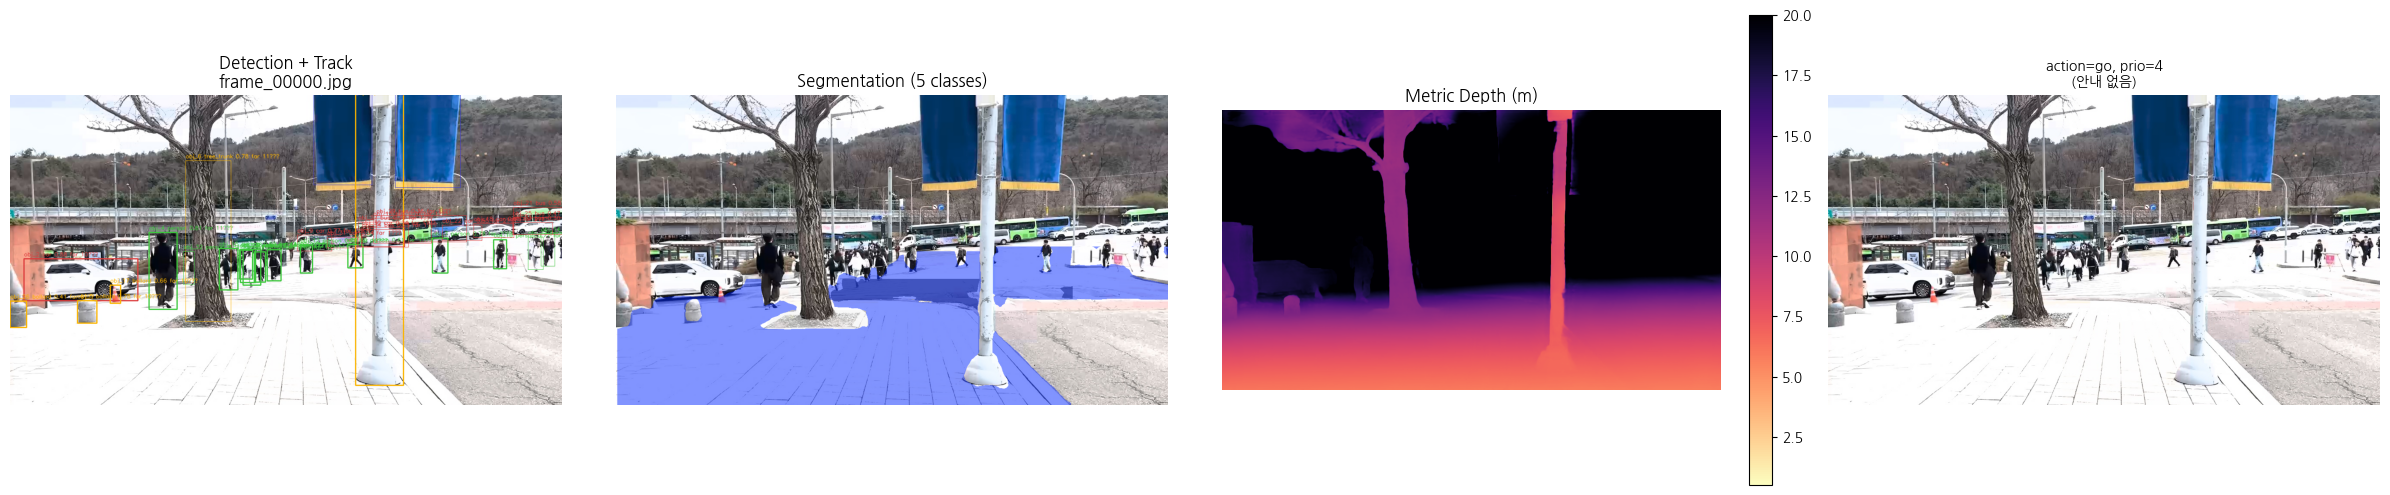

In [46]:
import json

track_history.clear()
last_announced_frame.clear()
det_model.predictor = None

test_idx = 0
result, depth_m, seg_res, seg_info, timings = process_frame(img_files[test_idx], frame_idx=test_idx)
print(json.dumps(result, ensure_ascii=False, indent=2))

print("\n=== 단계별 처리시간 (ms) ===")
for k, v in timings.items():
    print(f"  {k:>22s}: {v:7.1f} ms")

visualize_frame(img_files[test_idx], result, depth_m, seg_res,
                save_path=os.path.join(OUTPUT_DIR, '_sanity_check.png'))


## 12. Detection 누락 분석 — `predict` vs `track`

`model.track()`은 ByteTrack 매칭을 거치므로 `model.predict()`보다 객체가 적게 나올 수 있다.
프레임 하나에서 두 모드를 비교하여 어떤 detection이 트래커에서 떨어지는지 본다.


In [47]:
# frame_00560 같은 케이스 분석. 가운데 프레임으로 골라서 확인.
analyze_idx = min(40, len(img_files) - 1)
img_path = img_files[analyze_idx]

# (1) predict 단독 (트래킹 없음)
pred_res = det_model.predict(
    source=str(img_path), imgsz=IMG_SIZE, conf=CONF_DET,
    save=False, verbose=False,
)[0]

# (2) track (트래킹 있음) — 단, 트래커 상태가 영향을 주므로 새로 시작
det_model.predictor = None  # 트래커 리셋
track_res = det_model.track(
    source=str(img_path), imgsz=IMG_SIZE, conf=CONF_DET,
    persist=False, tracker='bytetrack.yaml',
    save=False, verbose=False,
)[0]

def _summarize(res):
    if res.boxes is None or len(res.boxes) == 0:
        return []
    cls_ids = res.boxes.cls.cpu().numpy().astype(int)
    confs = res.boxes.conf.cpu().numpy()
    return [(DET_CLASS_NAMES[int(c)], float(cf)) for c, cf in zip(cls_ids, confs)]

pred_list = _summarize(pred_res)
track_list = _summarize(track_res)

print(f"=== {img_path.name} ===")
print(f"\n[predict]  {len(pred_list)}개 검출:")
for nm, cf in sorted(pred_list, key=lambda x: -x[1]):
    print(f"  {nm:20s} conf={cf:.2f}")

print(f"\n[track]    {len(track_list)}개 검출:")
for nm, cf in sorted(track_list, key=lambda x: -x[1]):
    print(f"  {nm:20s} conf={cf:.2f}")

print(f"\n=> track에서 빠진 객체 수: {len(pred_list) - len(track_list)}")
print("(ByteTrack은 confidence 낮은 detection 일부를 매칭/생존 판단에서 제외)")


=== frame_00560.jpg ===

[predict]  4개 검출:
  person               conf=0.78
  bus                  conf=0.77
  truck                conf=0.72
  car                  conf=0.67

[track]    23개 검출:
  car                  conf=0.93
  person               conf=0.86
  person               conf=0.84
  car                  conf=0.81
  person               conf=0.80
  person               conf=0.79
  person               conf=0.78
  bus                  conf=0.77
  person               conf=0.73
  bollard              conf=0.73
  bus                  conf=0.73
  truck                conf=0.72
  person               conf=0.69
  car                  conf=0.67
  person               conf=0.63
  pole                 conf=0.55
  car                  conf=0.48
  pole                 conf=0.46
  bus                  conf=0.42
  bollard              conf=0.30
  person               conf=0.30
  person               conf=0.28
  person               conf=0.25

=> track에서 빠진 객체 수: -19
(ByteTrack은 confidenc

## 13. 전체 프레임 일괄 처리

In [48]:
import json
from tqdm import tqdm

track_history.clear()
last_announced_frame.clear()
det_model.predictor = None

N_VIZ = len(img_files)

all_results = []
all_timings = []
for fi, img_path in enumerate(tqdm(img_files, desc="Processing")):
    res, depth_m, seg_res, seg_info, timings = process_frame(img_path, frame_idx=fi)
    all_results.append(res)
    all_timings.append(timings)

    with open(os.path.join(JSON_DIR, f"{img_path.stem}.json"), 'w', encoding='utf-8') as f:
        json.dump(res, f, ensure_ascii=False, indent=2)

    if fi < N_VIZ or res['gt']['warning_needed']:
        save_path = os.path.join(VIZ_DIR, f"{img_path.stem}_viz.png")
        try:
            visualize_frame(img_path, res, depth_m, seg_res, save_path=save_path)
            plt.close('all')
        except Exception as e:
            print(f"viz fail {img_path.name}: {e}")

with open(os.path.join(OUTPUT_DIR, 'all_results.jsonl'), 'w', encoding='utf-8') as f:
    for r in all_results:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

print(f"\n총 {len(all_results)}장 처리 완료")


Output hidden; open in https://colab.research.google.com to view.

## 14. 단계별 처리시간 통계

In [49]:
# 각 단계별 ms 통계
stages = ['segmentation', 'detection_track', 'depth', 'postprocess', 'total']

print(f"=== 단계별 처리시간 (ms, n={len(all_timings)} frames) ===")
print(f"{'단계':<22s} {'평균':>8s} {'최소':>8s} {'중앙값':>8s} {'최대':>8s} {'FPS':>8s}")
print("-" * 70)
for stage in stages:
    arr = np.array([t.get(stage, 0.0) for t in all_timings])
    mean = arr.mean()
    fps = 1000.0 / mean if mean > 0 else 0
    print(f"{stage:<22s} {mean:>7.1f}  {arr.min():>7.1f}  {np.median(arr):>7.1f}  {arr.max():>7.1f}  {fps:>7.1f}")

# detection 모델 자체의 inference time만 (Ultralytics speed dict)
inf_times = [t.get('detection_inference_only', 0.0) for t in all_timings if 'detection_inference_only' in t]
if inf_times:
    inf_arr = np.array(inf_times)
    print(f"\n참고 - YOLO detection inference만 (ultralytics 보고치):")
    print(f"  평균 {inf_arr.mean():.1f} ms ({1000/inf_arr.mean():.1f} FPS)")

# 단계 비중
print(f"\n=== 단계 비중 (전체 대비 %) ===")
total_mean = np.mean([t['total'] for t in all_timings])
for stage in ['segmentation', 'detection_track', 'depth', 'postprocess']:
    arr = np.array([t.get(stage, 0.0) for t in all_timings])
    pct = arr.mean() / total_mean * 100 if total_mean > 0 else 0
    bar = '█' * int(pct / 2)
    print(f"  {stage:<22s} {arr.mean():>6.1f}ms  {pct:5.1f}%  {bar}")


=== 단계별 처리시간 (ms, n=93 frames) ===
단계                           평균       최소      중앙값       최대      FPS
----------------------------------------------------------------------
segmentation              10.2      9.1     10.0     21.4     97.8
detection_track           12.1      9.7     11.8     20.0     82.5
depth                     31.5     30.9     31.3     33.7     31.8
postprocess                6.5      4.4      6.5      8.8    154.7
total                     64.7     59.5     64.2     75.8     15.5

참고 - YOLO detection inference만 (ultralytics 보고치):
  평균 3.1 ms (318.7 FPS)

=== 단계 비중 (전체 대비 %) ===
  segmentation             10.2ms   15.8%  ███████
  detection_track          12.1ms   18.7%  █████████
  depth                    31.5ms   48.7%  ████████████████████████
  postprocess               6.5ms   10.0%  ████


## 15. gt만 모은 JSON 저장

In [50]:
gt_only = []
for r in all_results:
    gt_only.append({
        'id': r['id'],
        'frame_idx': r['frame_idx'],
        'gt': r['gt'],
    })

GT_ONLY_PATH = os.path.join(OUTPUT_DIR, 'gt_only.json')
with open(GT_ONLY_PATH, 'w', encoding='utf-8') as f:
    json.dump(gt_only, f, ensure_ascii=False, indent=2)

print(f"gt-only JSON 저장: {GT_ONLY_PATH}")
print(f"  총 {len(gt_only)}개 프레임")
print("\n=== 미리보기 (앞 3개) ===")
print(json.dumps(gt_only[:3], ensure_ascii=False, indent=2))


gt-only JSON 저장: /content/drive/MyDrive/capstone/results/integrated_pipeline_v4/gt_only.json
  총 93개 프레임

=== 미리보기 (앞 3개) ===
[
  {
    "id": "frame_00000",
    "frame_idx": 0,
    "gt": {
      "warning_needed": false,
      "primary_object_id": null,
      "primary_object_class": null,
      "primary_object_class_ko": null,
      "clock_direction": null,
      "distance": null,
      "action": "go",
      "priority": 4,
      "reason": "경로상 위험 없음",
      "voice_guide": ""
    }
  },
  {
    "id": "frame_00014",
    "frame_idx": 1,
    "gt": {
      "warning_needed": false,
      "primary_object_id": null,
      "primary_object_class": null,
      "primary_object_class_ko": null,
      "clock_direction": null,
      "distance": null,
      "action": "go",
      "priority": 4,
      "reason": "경로상 위험 없음",
      "voice_guide": ""
    }
  },
  {
    "id": "frame_00028",
    "frame_idx": 2,
    "gt": {
      "warning_needed": false,
      "primary_object_id": null,
      "primary_object_c

## 16. 결과 요약

In [51]:
from collections import Counter

actions = Counter(r['gt']['action'] for r in all_results)
print("=== Action 분포 ===")
for a, n in actions.most_common():
    print(f"  {a:>8s}: {n:>3d} ({n/len(all_results)*100:5.1f}%)")

wn = sum(1 for r in all_results if r['gt']['warning_needed'])
print(f"\nwarning_needed=True: {wn}/{len(all_results)} ({wn/len(all_results)*100:.1f}%)")

tl  = sum(1 for r in all_results if r['scene']['traffic_light']['exists'])
cw  = sum(1 for r in all_results if r['scene']['crosswalk']['exists'])
tb  = sum(1 for r in all_results if r['scene']['tactile_block']['exists'])
print(f"\ntraffic_light 검출: {tl}/{len(all_results)}")
print(f"crosswalk     검출: {cw}/{len(all_results)}")
print(f"tactile_block 검출: {tb}/{len(all_results)}")

warned_classes = Counter()
for r in all_results:
    g = r['gt']
    if g['warning_needed'] and g['primary_object_class_ko']:
        warned_classes[g['primary_object_class_ko']] += 1
print(f"\n=== 안내된 객체 분포 ===")
for cls, n in warned_classes.most_common():
    print(f"  {cls:>10s}: {n:>3d}")

# 안내된 객체의 거리 분포
print(f"\n=== Action별 primary 객체 거리 ===")
for a in ['stop', 'detour', 'caution']:
    distances = []
    for r in all_results:
        if r['gt']['action'] != a:
            continue
        pid = r['gt']['primary_object_id']
        if not pid:
            continue
        for o in r['scene']['objects']:
            if o['object_id'] == pid and o.get('distance_m') is not None:
                distances.append(o['distance_m'])
                break
    if distances:
        print(f"  {a:>8s}: n={len(distances)}, "
              f"mean={np.mean(distances):.2f}m, "
              f"median={np.median(distances):.2f}m, "
              f"max={max(distances):.2f}m")


=== Action 분포 ===
        go:  83 ( 89.2%)
      stop:   9 (  9.7%)
    detour:   1 (  1.1%)

warning_needed=True: 10/93 (10.8%)

traffic_light 검출: 52/93
crosswalk     검출: 41/93
tactile_block 검출: 42/93

=== 안내된 객체 분포 ===
          차량:   9
          기둥:   1

=== Action별 primary 객체 거리 ===
      stop: n=9, mean=3.36m, median=3.37m, max=3.58m
    detour: n=1, mean=3.80m, median=3.80m, max=3.80m


## 17. 샘플 JSON 출력 미리보기

In [52]:
warn_results = [r for r in all_results if r['gt']['warning_needed']]
if warn_results:
    print(f"\n=== 첫 warning 프레임: {warn_results[0]['id']} ===")
    print(json.dumps(warn_results[0], ensure_ascii=False, indent=2))
else:
    print("warning 발생한 프레임 없음")



=== 첫 warning 프레임: frame_00560 ===
{
  "id": "frame_00560",
  "frame_idx": 40,
  "scene": {
    "tactile_block": {
      "exists": false,
      "blocked": false,
      "broken": false
    },
    "crosswalk": {
      "exists": false
    },
    "walkable": {
      "exists": true
    },
    "caution_zone": {
      "exists": false
    },
    "roadway": {
      "exists": false
    },
    "traffic_light": {
      "exists": false,
      "color": "none"
    },
    "depth_zones": {
      "left": {
        "nearest_m": 3.54,
        "status": "safe",
        "priority": 0
      },
      "center": {
        "nearest_m": 5.71,
        "status": "safe",
        "priority": 0
      },
      "right": {
        "nearest_m": 5.71,
        "status": "safe",
        "priority": 0
      }
    },
    "objects": [
      {
        "object_id": "obj_1",
        "class": "car",
        "class_ko": "차량",
        "confidence": 0.935,
        "bbox_xyxy": [
          867.2,
          317.3,
          1279.6,
   